In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [2]:
import torch.nn as nn

class MLPModel(nn.Module):
    def __init__(self, input_dim=10, hidden_dim=64, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

In [3]:
import torch
import torch.nn as nn

class HyperbolicLoss(nn.Module):  # Custom loss for hyperbolic projection
    def __init__(self, alpha=1.0, beta=0.5, gamma=1.0, delta=1.0):
        super(HyperbolicLoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.delta = delta

    def projection(self, x, eps=1e-5):
        norm = torch.norm(x, dim=-1, keepdim=True).clamp_min(eps)
        return (torch.tanh(norm) / norm) * x  # Projects onto Poincaré ball

    def poincare_distance(self, u, v, eps=1e-5):
        norm_u = torch.clamp(torch.norm(u, dim=-1), max=1 - eps)
        norm_v = torch.clamp(torch.norm(v, dim=-1), max=1 - eps)
        diff = torch.norm(u - v, dim=-1)
        numerator = 2 * diff ** 2
        denominator = (1 - norm_u**2) * (1 - norm_v**2)
        cosh_arg = 1 + numerator / denominator
        return torch.acosh(torch.clamp(cosh_arg, min=1 + eps)).mean()

    def forward(self, predictions, targets):
        # predictions: shape [batch_size, 2]
        # targets: shape [batch_size], scalar values

        # Convert scalar targets into 2D vectors (e.g., [0, y])
        targets_2d = torch.stack([torch.zeros_like(targets), targets], dim=1)

        # Standard Euclidean error
        loss_l2 = torch.norm(predictions - targets_2d, p=2) ** 2
        loss_l1 = torch.norm(predictions - targets_2d, p=1)

        # Project to Poincaré ball
        proj_pred = self.projection(predictions)
        proj_true = self.projection(targets_2d)

        # Compute geometric distance
        geom_error = self.poincare_distance(proj_pred, proj_true)

        # Add L1 norm of geometric error (optional; geom_error is scalar already)
        norm_geom = torch.norm(geom_error, p=1)

        return self.alpha * loss_l2 + self.beta * loss_l1 + self.gamma * geom_error + self.delta * norm_geom



In [28]:
data = pd.read_csv('SRU2Limpio.csv')

X = data.iloc[:,:10].values.astype(np.float32)
y = data.iloc[:,10].values.astype(np.float32)

scalerx = StandardScaler()
scalery = StandardScaler()

Xscaled = scalerx.fit_transform(X)
yscaled = scalery.fit_transform(y.reshape(-1,1)).flatten()

xtensor = torch.tensor(Xscaled)
ytensor = torch.tensor(yscaled)


print(f'shape input: {xtensor.shape}, shape output: {ytensor.shape}')

shape input: torch.Size([84241, 10]), shape output: torch.Size([84241])


In [30]:
from torch.utils.data import DataLoader, TensorDataset

n = len(xtensor)
n_train = int(0.7 * n)
n_val = int(0.15 * n)
n_test = n - n_train - n_val

X_train = xtensor[:n_train]
y_train = ytensor[:n_train]

X_val = xtensor[n_train:n_train + n_val]
y_val = ytensor[n_train:n_train + n_val]

X_test = xtensor[n_train + n_val:]
y_test = ytensor[n_train + n_val:]

batch_size = 64

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=False)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

#hiperparametros
alpha = 1
beta = 0
gamma = 0
delta = 0
lr= 0.0001
epochs = 60
lambdal2 = 1

model = MLPModel(input_dim=10, output_dim=2).to(device)
criterion = HyperbolicLoss(alpha=alpha, beta=beta, gamma=gamma, delta=delta)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [6]:
#listas para guardar errores
maelist = []
mselist = []
r2list = []
mapelist = []
#2 son los no geometricos
maelist2 = []
mselist2 = []
r2list2 = []
mapelist2 = []

for i in range(50):
    print(f'iteration: {i}')
    train_losses = []
    val_losses = []

    previous_params =0
    previous_params = [param.detach().clone() for param in model.parameters() if param.requires_grad]

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            #weight penalty
            l2penalty = 0
            for param, prev_param in zip(model.parameters(), previous_params):
                if param.requires_grad:
                    l2penalty += torch.norm(param-prev_param, p=2)**2

            losstotal = loss + lambdal2*l2penalty
            #####
            losstotal.backward()
            optimizer.step()
        
            train_loss += loss.item()
            
        previous_params = [p.detach().clone() for p in model.parameters() if p.requires_grad]
            
        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():     
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        #print(f'Epoch {epoch+1} ||  Train Loss: {train_loss:.6f},  Validation Loss: {val_loss:.6f}')

        model.eval()
        all_preds = []
        all_targets = []

        with torch.no_grad(): #torch no grad hace que no se actualicen los pesos, lo que se hace para validar y no entrenar
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                preds = model(X_batch)
                all_preds.append(preds.cpu())
                all_targets.append(y_batch)

        all_preds = scalery.inverse_transform(torch.cat(all_preds).squeeze().numpy().reshape(-1, 1)).flatten() #se hace la transformada inversa de la normalizacion para obtener los datos reales.
        all_targets = scalery.inverse_transform(torch.cat(all_targets).squeeze().numpy().reshape(-1, 1)).flatten()

        from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

        r2 = r2_score(all_targets, all_preds)
        mse = mean_squared_error(all_targets, all_preds)
        mae = mean_absolute_error(all_targets, all_preds)
        mape = mean_absolute_percentage_error(all_targets, all_preds)
        print(f"R² Score: {r2:.6f}")
        print(f"MSE: {mse:.6f}")
        print(f"MAE: {mae:.6f}")
        print(f'MAPE: {mape:.6f}')
        r2list.append(r2)
        mselist.append(mse)
        maelist.append(mae)
        mapelist.append(mape)


iteration: 0


RuntimeError: The size of tensor a (2) must match the size of tensor b (64) at non-singleton dimension 1

Epoch 1 ||  Train Loss: 42.845477,  Validation Loss: 4.359378
Epoch 2 ||  Train Loss: 25.313471,  Validation Loss: 4.693583
Epoch 3 ||  Train Loss: 23.448980,  Validation Loss: 4.569356
Epoch 4 ||  Train Loss: 21.341543,  Validation Loss: 4.295357
Epoch 5 ||  Train Loss: 19.950354,  Validation Loss: 4.028970
Epoch 6 ||  Train Loss: 18.888695,  Validation Loss: 3.783142
Epoch 7 ||  Train Loss: 18.016745,  Validation Loss: 3.586923
Epoch 8 ||  Train Loss: 17.246699,  Validation Loss: 3.390305
Epoch 9 ||  Train Loss: 16.480757,  Validation Loss: 3.224977
Epoch 10 ||  Train Loss: 15.859393,  Validation Loss: 3.104695
Epoch 11 ||  Train Loss: 15.198515,  Validation Loss: 3.009275
Epoch 12 ||  Train Loss: 14.565278,  Validation Loss: 2.942908
Epoch 13 ||  Train Loss: 13.971939,  Validation Loss: 2.892811
Epoch 14 ||  Train Loss: 13.398052,  Validation Loss: 2.854991
Epoch 15 ||  Train Loss: 12.842249,  Validation Loss: 2.826378
Epoch 16 ||  Train Loss: 12.309962,  Validation Loss: 2.786751
E

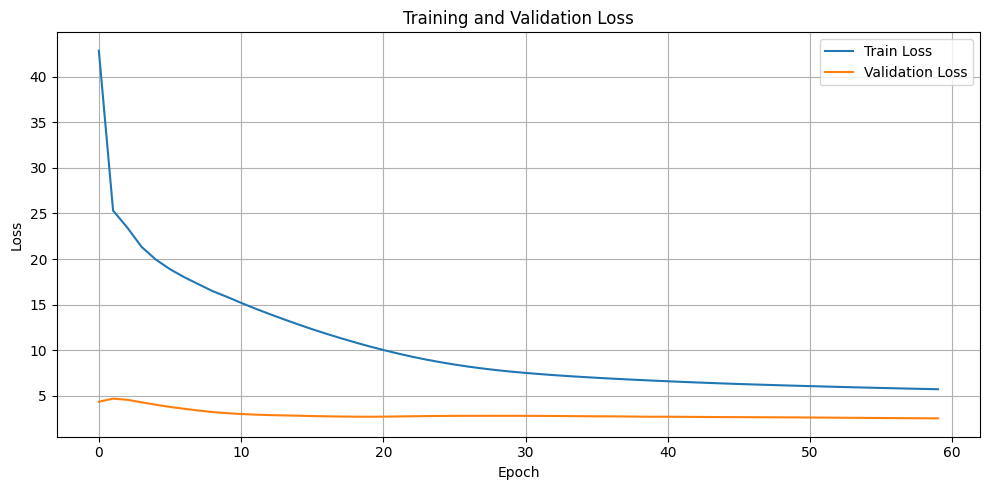

In [31]:
train_losses = []
val_losses = []

previous_params =0
previous_params = [param.detach().clone() for param in model.parameters() if param.requires_grad]

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        #weight penalty
        l2penalty = 0
        for param, prev_param in zip(model.parameters(), previous_params):
            if param.requires_grad:
                l2penalty += torch.norm(param-prev_param, p=2)**2

        losstotal = loss + lambdal2*l2penalty
        #####
        losstotal.backward()
        optimizer.step()
    
        train_loss += loss.item()
        
    previous_params = [p.detach().clone() for p in model.parameters() if p.requires_grad]
        
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():     
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f'Epoch {epoch+1} ||  Train Loss: {train_loss:.6f},  Validation Loss: {val_loss:.6f}')

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

(25272,)
(12636,)


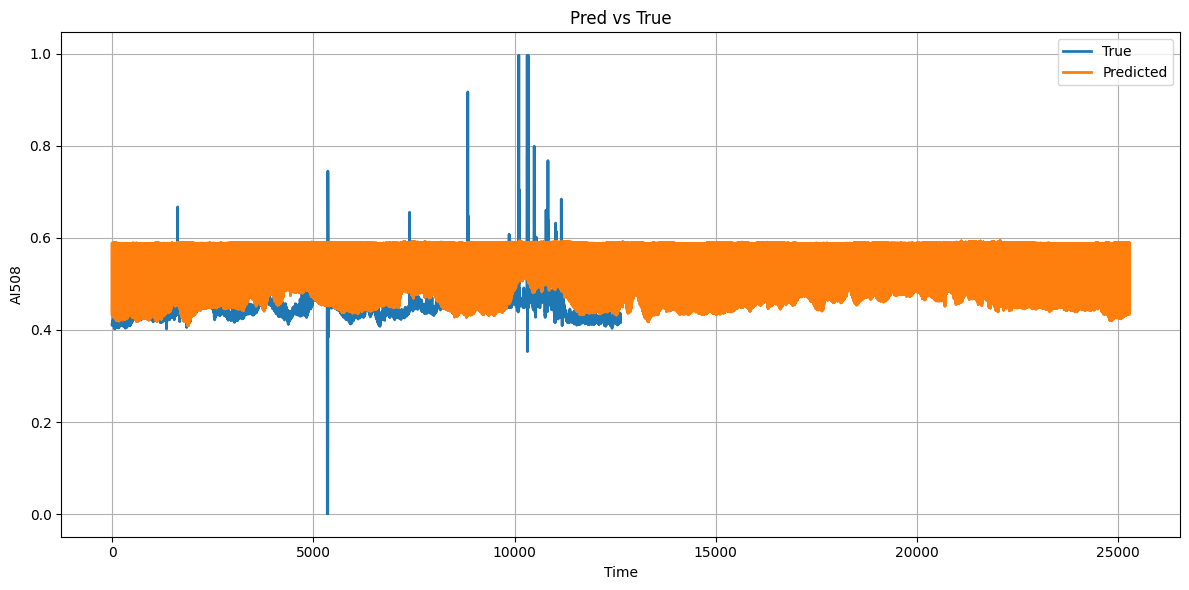

In [7]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch)
        all_preds.append(preds.cpu())
        all_targets.append(y_batch)

all_preds = scalery.inverse_transform(torch.cat(all_preds).squeeze().numpy().reshape(-1, 1)).flatten()
all_targets = scalery.inverse_transform(torch.cat(all_targets).squeeze().numpy().reshape(-1, 1)).flatten()
print(all_preds.shape)
print(all_targets.shape)

plt.figure(figsize=(12, 6))
plt.plot(all_targets, label='True', linewidth=2)
plt.plot(all_preds, label='Predicted', linewidth=2)
plt.xlabel('Time')
plt.ylabel('AI508')
plt.title('Pred vs True')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2 = r2_score(all_targets, all_preds)
mse = mean_squared_error(all_targets, all_preds)
mae = mean_absolute_error(all_targets, all_preds)

print("\Test Metrics:")
print(f"R² Score: {r2:.8f}")
print(f"MSE: {mse:.8f}")
print(f"MAE: {mae:.8f}")

<>:7: SyntaxWarning: invalid escape sequence '\T'
<>:7: SyntaxWarning: invalid escape sequence '\T'
C:\Users\Tomás\AppData\Local\Temp\ipykernel_19968\4117103884.py:7: SyntaxWarning: invalid escape sequence '\T'
  print("\Test Metrics:")
C:\Users\Tomás\AppData\Local\Temp\ipykernel_19968\4117103884.py:7: SyntaxWarning: invalid escape sequence '\T'
  print("\Test Metrics:")


ValueError: Found input variables with inconsistent numbers of samples: [12636, 25272]

(12636,)
(12636,)


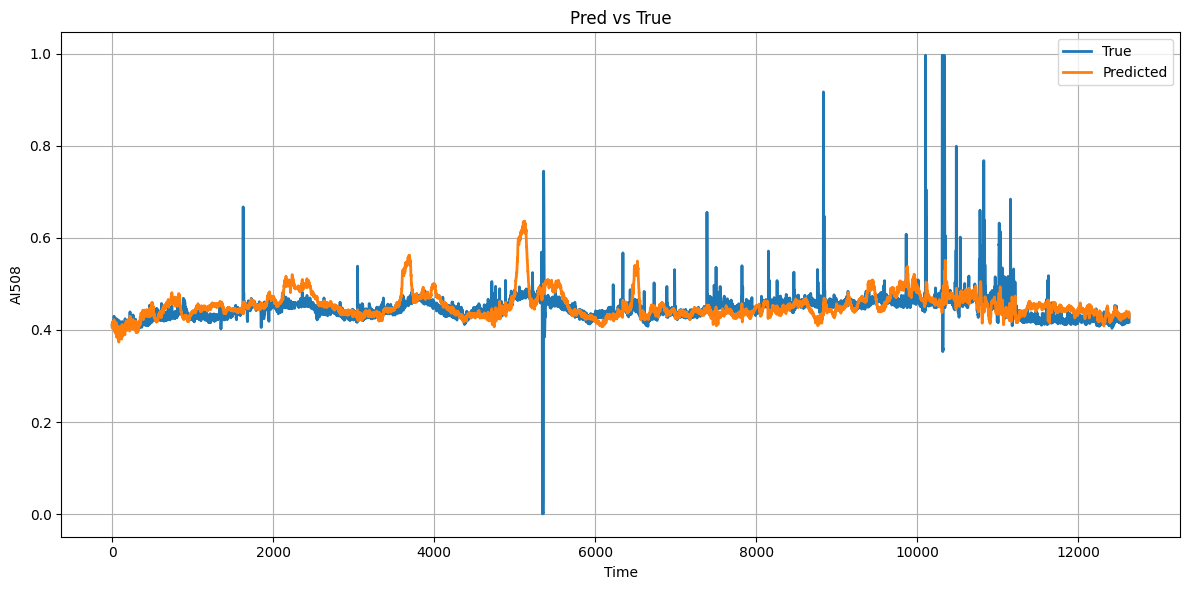

In [32]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch)[:, 1] 
        all_preds.append(preds.cpu())
        all_targets.append(y_batch)

all_preds = scalery.inverse_transform(torch.cat(all_preds).squeeze().numpy().reshape(-1, 1)).flatten()
all_targets = scalery.inverse_transform(torch.cat(all_targets).squeeze().numpy().reshape(-1, 1)).flatten()
print(all_preds.shape)
print(all_targets.shape)

plt.figure(figsize=(12, 6))
plt.plot(all_targets, label='True', linewidth=2)
plt.plot(all_preds, label='Predicted', linewidth=2)
plt.xlabel('Time')
plt.ylabel('AI508')
plt.title('Pred vs True')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

r2 = r2_score(all_targets, all_preds)
mse = mean_squared_error(all_targets, all_preds)
mae = mean_absolute_error(all_targets, all_preds)
mape = mean_absolute_percentage_error(all_targets, all_preds)

print("\Test Metrics:")
print(f"R² Score: {r2:.8f}")
print(f"MSE: {mse:.8f}")
print(f"MAE: {mae:.8f}")
print(f"MAPE: {mape:.8f}")

\Test Metrics:
R² Score: -0.24036264
MSE: 0.00132768
MAE: 0.01963711
MAPE: 0.44414076


<>:8: SyntaxWarning: invalid escape sequence '\T'
<>:8: SyntaxWarning: invalid escape sequence '\T'
C:\Users\Tomás\AppData\Local\Temp\ipykernel_19968\2102768520.py:8: SyntaxWarning: invalid escape sequence '\T'
  print("\Test Metrics:")
